# FNCE 449 Day 1 Assignment: Pairs Trading

**Assignment Instructions:**

1. **Select two correlated instruments and download data**
    - Download two years of data (e.g., July 1, 2023, to July 1, 2025) for two correlated instruments from Databento.
    - **Save the files locally to prevent querying Databento each time you run the code**.
    - Use hourly OHLCV data to enable higher frequency trading.

2. **Train the quantitative model**
   - Use only the *first* year of data to train the model.
   - Compute the price ratio $R_t=\frac{P_A}{P_B}$ and estimate the in-class regression: $$R_t-R_{t-1}=c-d \times R_{t-1} + \epsilon$$.
   - Set the threshold ratio for trading $\frac{c}{d}$.

3. **Implement the strategy**
    - Use only the *second* year of data to implement the model.
    - When $R_t>\frac{c}{d}$, then buy one stock $B$ and go short one stock $A$.
    - When $R_t<\frac{c}{d}$, buy one stock $A$ and go short one stock $B$.
    - Do not exceed one stock position at any time.
    - Keep track of your cash flow and mark-to-market your position over time.

4. **Performance Evaluation**
   - Calculate and plot the dollar value of your long-short portfolio over time.
   - Plot the number of trades over time.

## 1. Data Collection Setup
Define the helper function used to retrieve historical market data from Databento.

In [6]:
import pandas as pd

def get_range(api_key, dataset, symbols, schema, start, end, limit=None):
    """Query the Databento historical API and return the result as a DataFrame."""
    import requests
    from io import StringIO
    from requests.auth import HTTPBasicAuth

    url = 'https://hist.databento.com/v0/timeseries.get_range'
    auth = HTTPBasicAuth(api_key, '')

    payload = {
        'dataset': dataset,
        'symbols': symbols,
        'schema': schema,
        'start': start,
        'end': end,
        'encoding': 'csv',
        'pretty_px': 'true',
        'pretty_ts': 'true',
        'map_symbols': 'true',
        'limit': limit,
    }

    response = requests.post(url, auth=auth, data=payload)
    return pd.read_csv(StringIO(response.content.decode('utf-8')))

### Download and Save DGX and LH Hourly Data
Download two years of hourly OHLCV data for DGX and LH and save it locally to avoid repeated Databento queries.

In [7]:
import databento as db

client = db.Historical("db-VfHVmJbwExnyLCsxG76uQLxiu4agb")

data = client.timeseries.get_range(
    dataset="EQUS.MINI",
    symbols=["DGX", "LH"],
    schema="ohlcv-1h",
    start="2023-07-01",
    end="2025-07-01",
)

df = data.to_df()

# Save locally so Databento isn't queried again
df.to_csv("DGX_LH_hourly.csv")

C:\Users\kamand.ghorbanzadeh\AppData\Local\Temp\ipykernel_18240\2665792130.py:5: BentoWarning: The streaming request contained one or more days which have reduced quality: 2025-03-24 (degraded), 2025-04-04 (degraded), 2025-05-06 (degraded)... See: https://databento.com/docs/api-reference-historical/metadata/metadata-get-dataset-condition
  data = client.timeseries.get_range(


## 2. Train the Quantitative Model
Use the first year of DGX and LH hourly price data to calculate the price ratio and estimate the mean-reversion regression.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

df = pd.read_csv("DGX_LH_hourly.csv", parse_dates=["ts_event"])

prices = (
    df.pivot_table(
        index="ts_event",
        columns="symbol",
        values="close",
        aggfunc="last"
    )
    .sort_index()
    .dropna(subset=["DGX", "LH"])
)

# Ratio: A / B = DGX / LH
prices["ratio"] = prices["DGX"] / prices["LH"]

train = prices[
    (prices.index >= pd.Timestamp("2023-07-01", tz="UTC")) &
    (prices.index < pd.Timestamp("2024-07-01", tz="UTC"))
].copy()

train["ratio_lag"] = train["ratio"].shift(1)

train["delta_ratio"] = (
    train["ratio"] - train["ratio_lag"]
)

reg_data = train.dropna()

X = sm.add_constant(reg_data["ratio_lag"])
y = reg_data["delta_ratio"]

model = sm.OLS(y, X).fit()

print(model.summary())

c = model.params["const"]
d = -model.params["ratio_lag"]

threshold = c / d
return_correlation = (train[["DGX", "LH"]].pct_change().dropna().corr().loc["DGX", "LH"])

print("c =", c)
print("d =", d)
print("Threshold =", threshold)
print("DGX-LH Hourly Return Correlation:",round(return_correlation, 3))

                            OLS Regression Results                            
Dep. Variable:            delta_ratio   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                     1.807
Date:                Mon, 24 Aug 2026   Prob (F-statistic):              0.179
Time:                        16:25:09   Log-Likelihood:                 7977.0
No. Observations:                1743   AIC:                        -1.595e+04
Df Residuals:                    1741   BIC:                        -1.594e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0014      0.001      1.344      0.1

## 3. Implement the Pairs Trading Strategy
Apply the estimated threshold to the second year of data to determine long and short positions for DGX and LH.

In [36]:
# Use only the second year of data for trading
test = prices.loc[
    "2024-07-01":"2025-06-30"
].copy()

# Trading rule:
# Ratio > threshold  -> Short DGX, Long LH
# Ratio < threshold  -> Long DGX, Short LH
test["position_DGX"] = np.where(
    test["ratio"] > threshold,
    -1,
    1
)

# LH always takes the opposite position
test["position_LH"] = -test["position_DGX"]

# Calculate trades needed when the position changes
test["trade_DGX"] = (
    test["position_DGX"]
    .diff()
    .fillna(test["position_DGX"])
)

test["trade_LH"] = -test["trade_DGX"]

# Identify when a trade occurs
test["trade_event"] = test["trade_DGX"] != 0

# Cash flow from each trade
test["cash_flow"] = -(
    test["trade_DGX"] * test["DGX"]
    + test["trade_LH"] * test["LH"]
)

# Running cash balance
test["cash"] = test["cash_flow"].cumsum()

# Mark-to-market value of the open positions
test["market_value"] = (
    test["position_DGX"] * test["DGX"]
    + test["position_LH"] * test["LH"]
)

# Total long-short portfolio value
test["portfolio_value"] = (
    test["cash"] + test["market_value"]
)
test[
    ["DGX","LH","ratio","position_DGX","position_LH","trade_DGX","trade_LH","cash_flow","cash","market_value","portfolio_value"]
].head(10)

symbol,DGX,LH,ratio,position_DGX,position_LH,trade_DGX,trade_LH,cash_flow,cash,market_value,portfolio_value
ts_event,,,,,,,,,,,
2024-07-01 13:00:00+00:00,138.930,206.020,0.674352,-1,1,-1.0,1.0,-67.09,-67.09,67.090,0.000
2024-07-01 14:00:00+00:00,137.630,203.810,0.675286,-1,1,0.0,-0.0,-0.00,-67.09,66.180,-0.910
2024-07-01 15:00:00+00:00,137.020,202.575,0.676391,-1,1,0.0,-0.0,-0.00,-67.09,65.555,-1.535
2024-07-01 16:00:00+00:00,137.130,202.880,0.675917,-1,1,0.0,-0.0,-0.00,-67.09,65.750,-1.340
2024-07-01 17:00:00+00:00,136.360,202.420,0.673649,-1,1,0.0,-0.0,-0.00,-67.09,66.060,-1.030
2024-07-01 18:00:00+00:00,136.700,201.840,0.677269,-1,1,0.0,-0.0,-0.00,-67.09,65.140,-1.950
2024-07-01 19:00:00+00:00,137.080,203.190,0.674639,-1,1,0.0,-0.0,-0.00,-67.09,66.110,-0.980
2024-07-02 13:00:00+00:00,137.150,202.180,0.678356,-1,1,0.0,-0.0,-0.00,-67.09,65.030,-2.060
2024-07-02 14:00:00+00:00,137.825,203.610,0.676907,-1,1,0.0,-0.0,-0.00,-67.09,65.785,-1.305


## 4. Performance Evaluation
### Portfolio Value Over Time
Plot the mark-to-market dollar value of the DGX-LH long-short portfolio over the second-year trading period.

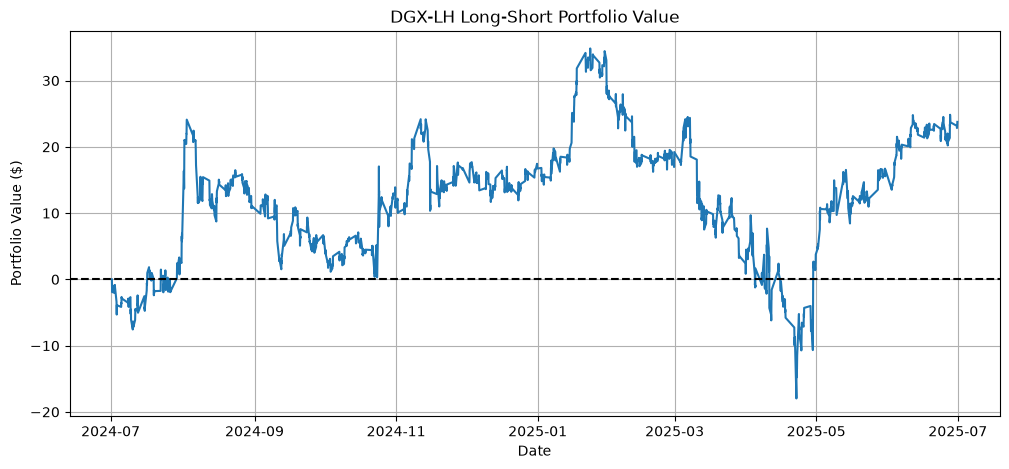

Final Portfolio Value: $ 23.76


In [33]:
plt.figure(figsize=(12, 5))

plt.plot(
    test.index,
    test["portfolio_value"]
)

plt.axhline(
    y=0,
    color="black",
    linestyle="--"
)

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("DGX-LH Long-Short Portfolio Value")
plt.grid()

plt.show()

print(
    "Final Portfolio Value: $",
    round(test["portfolio_value"].iloc[-1], 2)
)

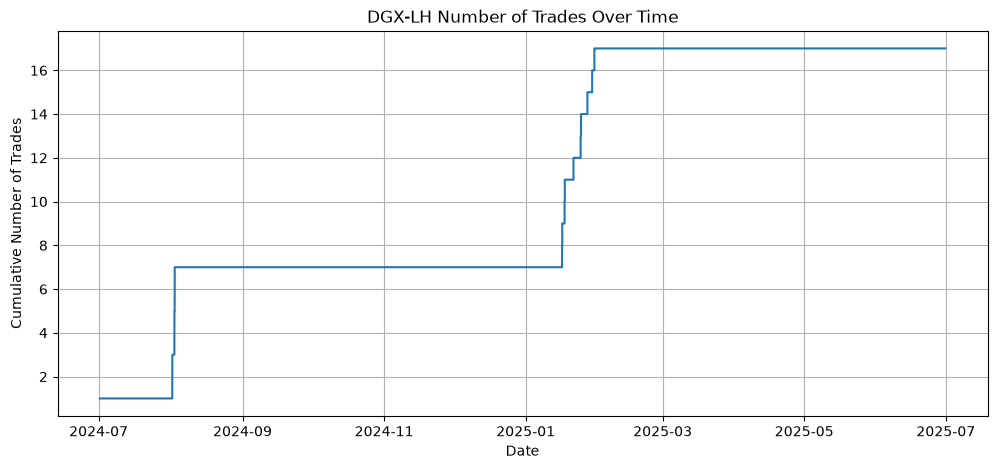

Total Number of Trades: 17


In [34]:
test["number_of_trades"] = test["trade_event"].cumsum()

plt.figure(figsize=(12, 5))

plt.step(
    test.index,
    test["number_of_trades"],
    where="post"
)

plt.xlabel("Date")
plt.ylabel("Cumulative Number of Trades")
plt.title("DGX-LH Number of Trades Over Time")
plt.grid()

plt.show()

print(
    "Total Number of Trades:",
    test["trade_event"].sum()
)